In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()

  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`
Precompiling packages...
   3835.7 ms  ✓ CausalSetZoology
  1 dependency successfully precompiled in 10 seconds. 418 already precompiled.


In [2]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

using Revise
includet("analysis.jl")

In [3]:
import Colors
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

In [4]:
candidates = [
    "/Volumes/Causal Set Silo/causal_sets/analysis/",
    "/Volumes/Causal Set Silochen/causal_sets/analysis/",
]

root_path = let p = findfirst(isdir, candidates)
    p === nothing && error("No analysis path found")
    candidates[p]
end

data_path_man = [joinpath(root_path,"manifoldlike_simply_connected_2048_10000/statistics.jld2")]

function data_paths(file_names::Vector{String})::Vector{String}
    return [joinpath(root_path, file_name) for file_name in file_names]
end

data_paths (generic function with 1 method)

In [6]:
data_paths_merged = ["/Volumes/Causal Set Silo/causal_sets/analysis/genus_256_10000/statistics.jld2"]
communicability_merged = load_fields_from_paths(data_paths_merged, [:communicability_hist_link], :genus)

1-element Vector{Vector{Any}}:
 [[([13.948743386243384, 15.558333984688153, 10.706481168061272, 10.80192405202822, 11.949939127551973, 8.47425954679, 10.1809596714371, 12.090277657013768, 10.80192405202822, 18.021201849847685  …  1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 5.0), ([5.971112915580352, 11.532958260930354, 8.5606247657941, 11.532958260930354, 11.532958260930354, 17.179913007912283, 7.933205544397834, 5.132640007518764, 10.051044539507592, 8.551044539507592  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 8.0), ([23.353781377935515, 37.479797091266526, 45.55120639582098, 11.023160882228227, 25.71520269226408, 15.031377261131725, 4.368880899468698, 50.29235258142282, 22.790151524715835, 43.38386171350397  …  3.5, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0], 6.0), ([54.16680504552672, 84.4803168514613, 25.92126287857315, 93.65435914549994, 75.55867538569261, 36.70724636606448, 48.034680479911685, 4.252359758297259, 11.22314484126984, 98.96179122849003  …  2.0, 2

In [21]:
communicability_merged_v = [(sort!(hist[1]), hist[2]) for hist in communicability_merged[1][1]]

groups = Dict{Float64, Vector{Vector{Float64}}}()

for (v, label) in communicability_merged_v
    push!(get!(groups, label, Vector{Float64}[]), v)
end

communicability_by_label = Dict{Float64, Vector{Tuple{Float64,Float64}}}()

for (label, vecs) in groups
    m = length(vecs)
    n = length(vecs[1])

    tmp = Vector{Float64}(undef, m)
    av_std = Vector{Tuple{Float64,Float64}}(undef, n)

    for i in 1:n
        @inbounds for j in 1:m
            tmp[j] = vecs[j][i]
        end
        av_std[i] = (mean(tmp), std(tmp))
    end

    communicability_by_label[label] = av_std
end



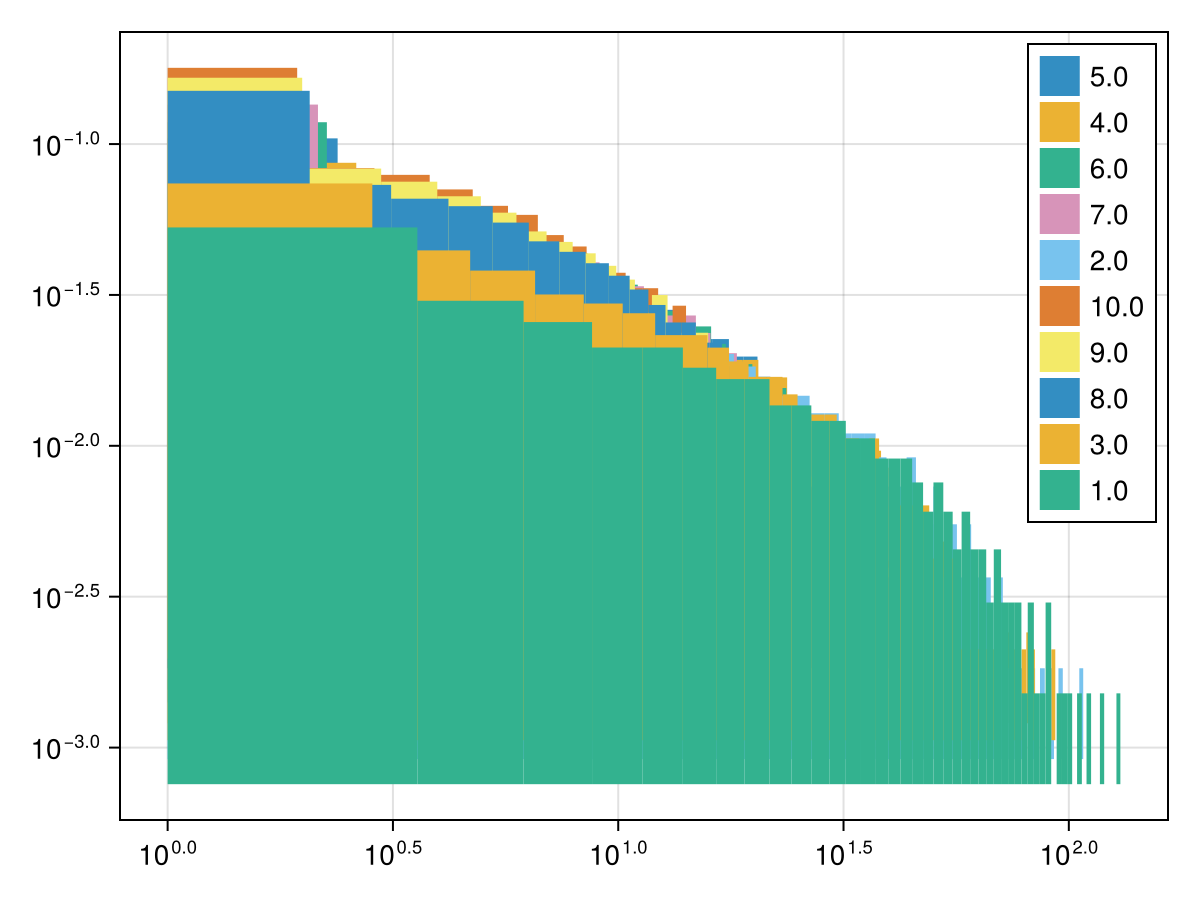

In [30]:
fig = Figure()
ax = Axis(fig[1, 1], xscale=log10, yscale=log10)

for (label, av_std_vec) in communicability_by_label
    μ = first.(av_std_vec)
    hist!(ax, μ; bins = 50, label = string(label), normalization = :pdf)
end

axislegend(ax)
fig
